In [2]:
pip install pandas matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 9.5 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/9.9 MB 9.5 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.9 MB 9.4 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 9.3 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.9 MB/s  0:00:01
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.4 MB 7.6 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.4 MB 7.6 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.4 MB 7.7 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.4 MB 7.5 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.4 MB 7.5 MB/s eta 0:00:01
   --------------------

In [8]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import openpyxl

# =========================================================
# 1. CONFIGURAÇÕES
# =========================================================
arquivo_xlsx = r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\base_dados_unificada_24032026.xlsx"
pasta_saida = Path(r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\graficos_por_data")
pasta_saida.mkdir(exist_ok=True)

# =========================================================
# 2. LEITURA DA PLANILHA
# =========================================================
df = pd.read_excel(arquivo_xlsx, engine="openpyxl")

<Axes: >

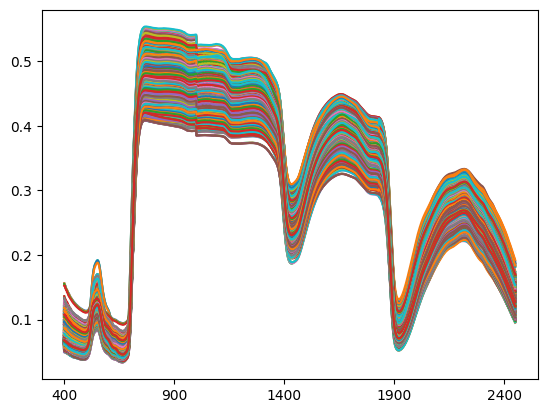

In [3]:
df.columns, 
df.loc[:,400:2450].T.plot(legend=False)

In [4]:
df

,nomenclaura,bloco,genotipo,condicao,data_coleta,turno,350,351,352,353,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,B1_BR16_IRRIG_REPROD00000.asd,B1,BR16,IRRIG,20170223,manha,0.123405,0.111624,0.100913,0.101923,...,0.096074,0.095822,0.095393,0.094591,0.094062,0.093659,0.093166,0.092958,0.092614,0.092480
1,B1_BR16_IRRIG_REPROD00001.asd,B1,BR16,IRRIG,20170223,manha,0.125185,0.112008,0.109146,0.104011,...,0.096357,0.095958,0.095621,0.095417,0.095530,0.094893,0.094280,0.094099,0.093564,0.092993
2,B1_BR16_IRRIG_REPROD00002.asd,B1,BR16,IRRIG,20170223,manha,0.133597,0.123323,0.118871,0.116672,...,0.097356,0.096105,0.095218,0.095313,0.095456,0.095035,0.094525,0.093557,0.092501,0.092824
3,B1_BR16_IRRIG_REPROD00003.asd,B1,BR16,IRRIG,20170223,manha,0.124457,0.113437,0.108990,0.104463,...,0.097453,0.097656,0.097715,0.097044,0.096482,0.096099,0.095550,0.095077,0.094707,0.093737
4,B1_BR16_IRRIG_REPROD00004.asd,B1,BR16,IRRIG,20170223,manha,0.133906,0.116968,0.112317,0.114166,...,0.088364,0.087896,0.087397,0.086768,0.086845,0.086859,0.086476,0.086283,0.085822,0.085195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,B4_EMB48_NIRR_REP_RECUP00003.asd,b4,BR16,NIRRIG,20170303,manha,0.115746,0.106084,0.099461,0.113083,...,0.090170,0.089455,0.088712,0.088320,0.087931,0.088062,0.087660,0.086519,0.085827,0.085312
1920,B4_EMB48_NIRR_REP_RECUP00004.asd,b4,BR16,NIRRIG,20170303,manha,0.108406,0.103772,0.105123,0.110151,...,0.092660,0.092253,0.091511,0.090695,0.090184,0.089917,0.089881,0.089218,0.088218,0.087603
1921,B4_EMB48_NIRR_REP_RECUP00005.asd,b4,BR16,NIRRIG,20170303,manha,0.116751,0.109934,0.113443,0.118783,...,0.093168,0.092823,0.092521,0.092100,0.091866,0.091585,0.091290,0.090565,0.089341,0.088646
1922,B4_EMB48_NIRR_REP_RECUP00006.asd,b4,BR16,NIRRIG,20170303,manha,0.116568,0.108093,0.106809,0.120845,...,0.094276,0.093820,0.093335,0.092819,0.092744,0.092647,0.092356,0.091959,0.091065,0.089984


# CORREÇÕES

✅ Pipeline final com visual científico executada!


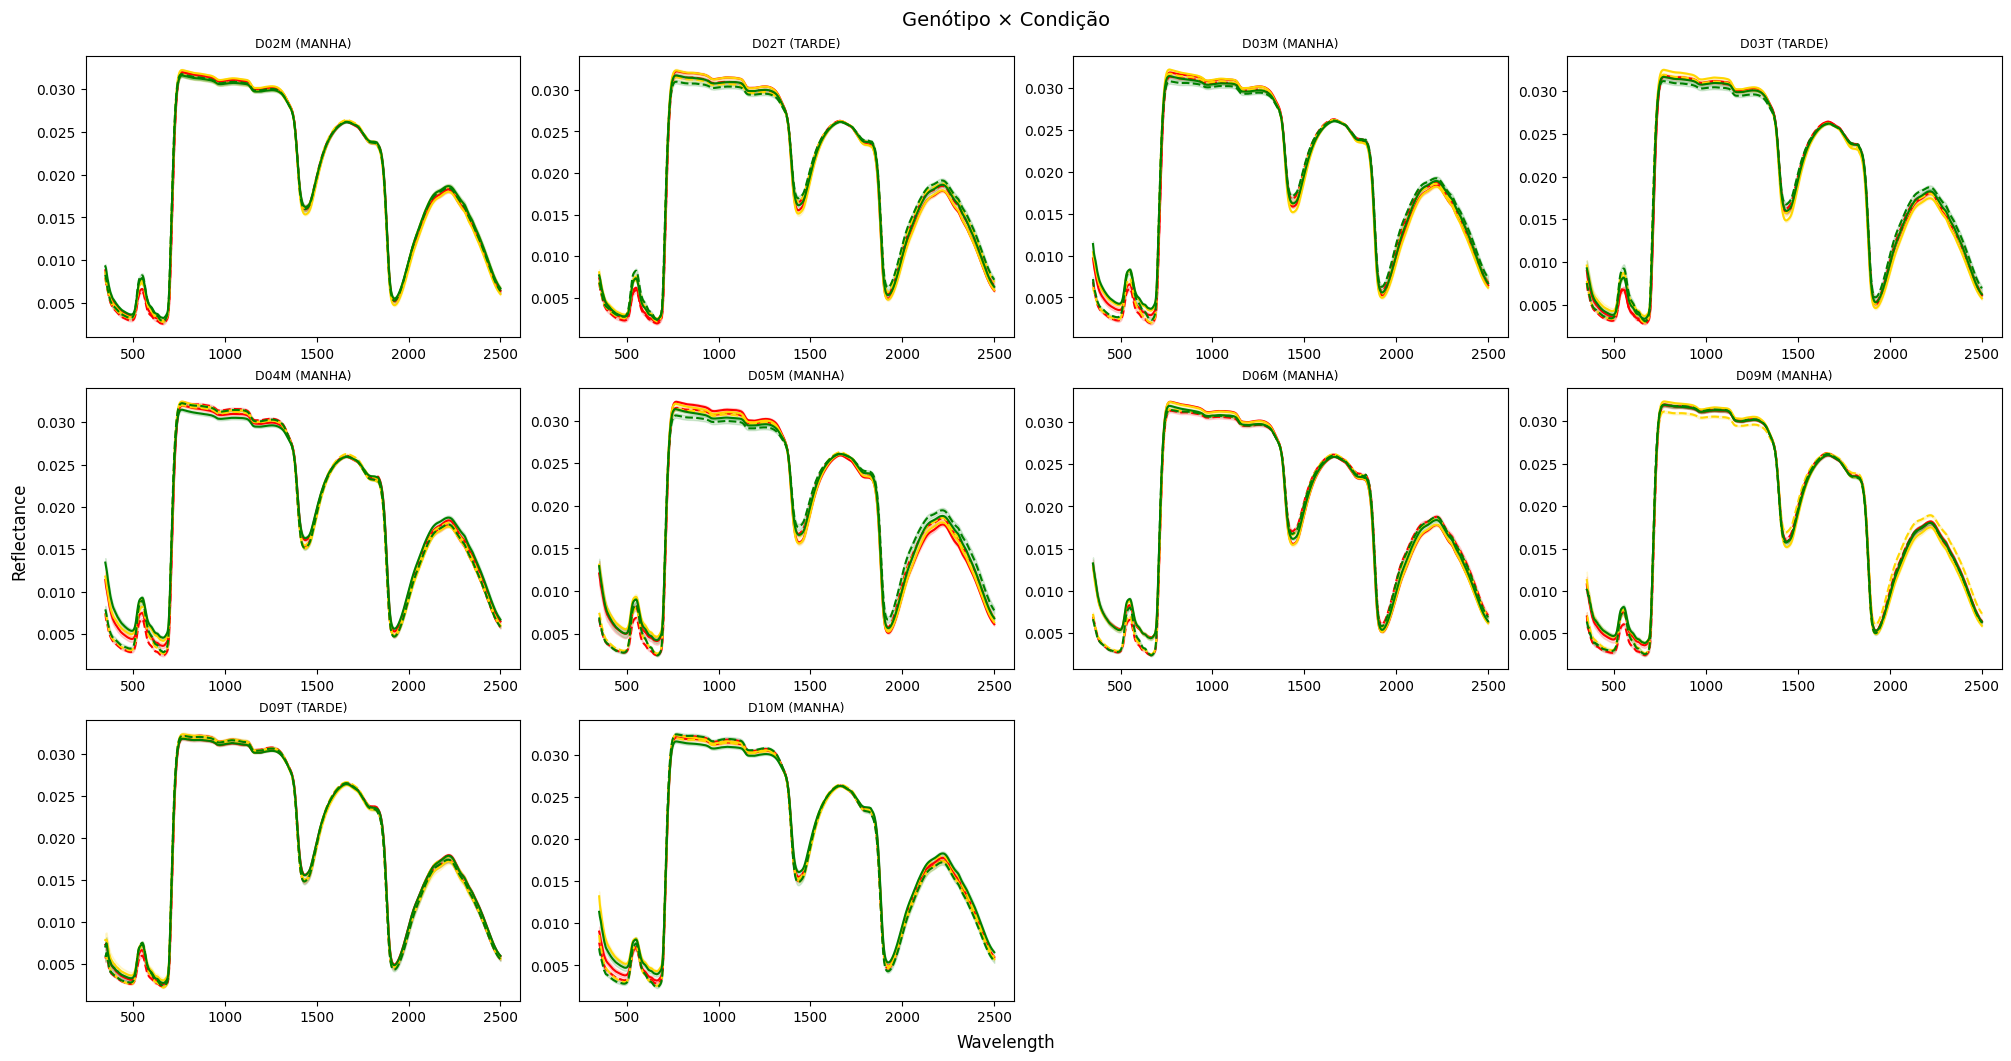

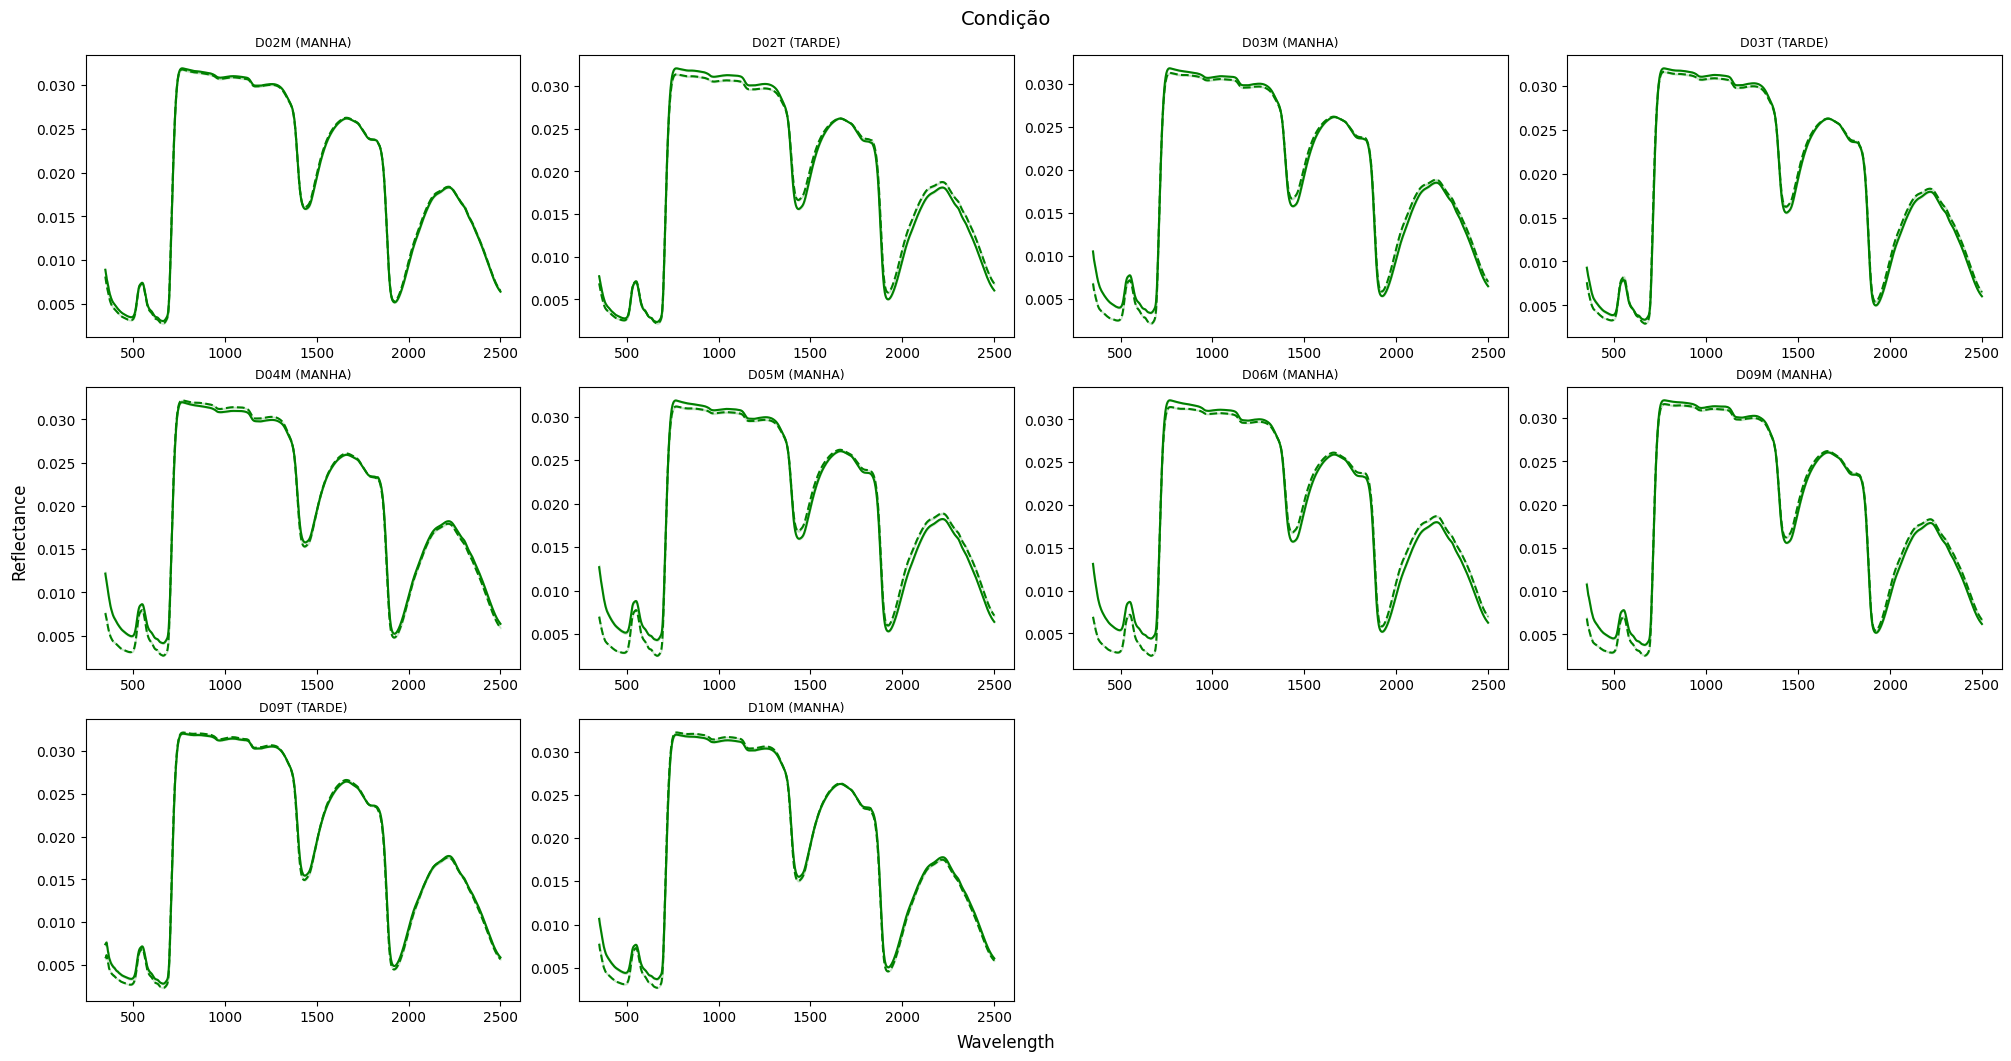

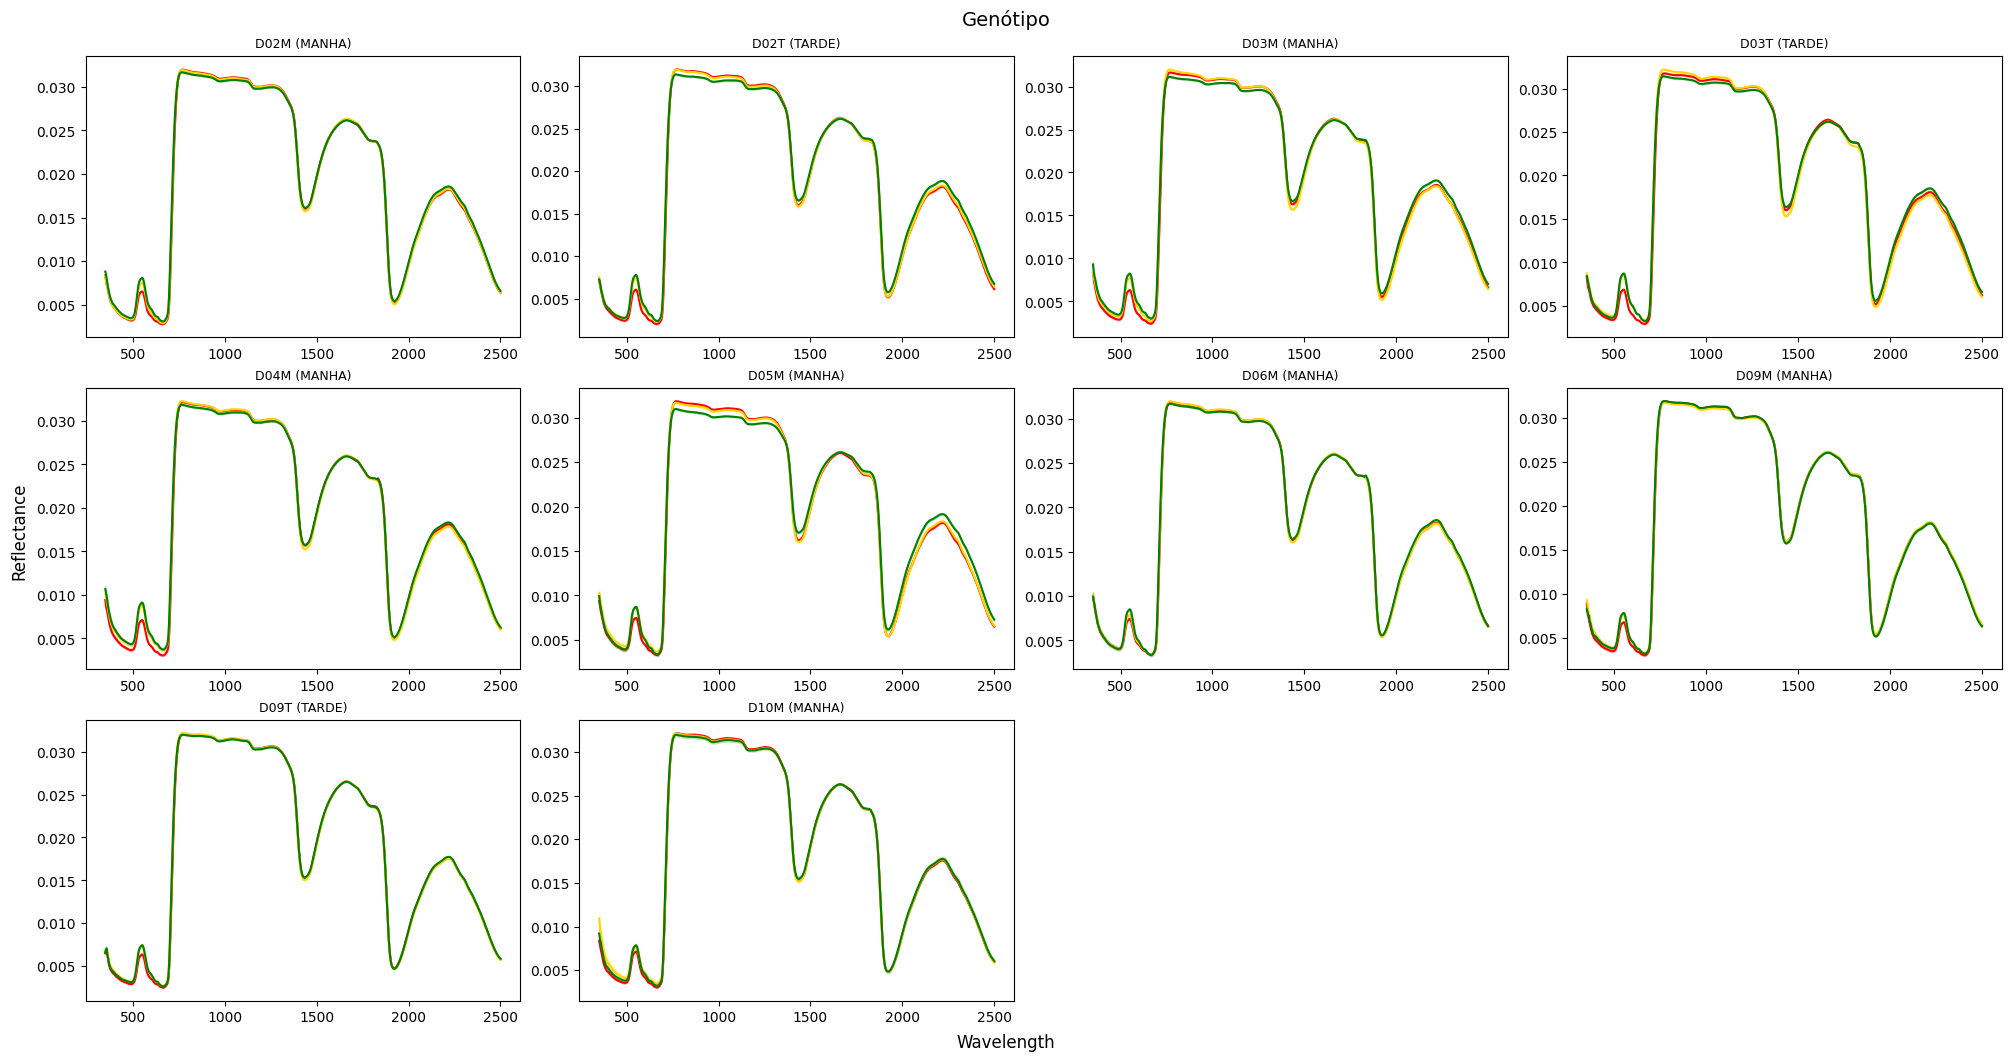

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t
from scipy.signal import savgol_filter
from sklearn.preprocessing import Normalizer

# =========================================================
# 1) CONFIG
# =========================================================
arquivo_xlsx = r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\base_dados_unificada_24032026.xlsx"
pasta_saida = Path(r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse")
pasta_saida.mkdir(exist_ok=True)

APLICAR_JUMP = True
APLICAR_SAVGOL = True
APLICAR_NORMALIZACAO = True

SPLICES = [1000, 1800]
REFERENCE_SEQ = 1
SAVGOL_WINDOW = 11
SAVGOL_POLY = 2

# =========================================================
# 2) LEITURA
# =========================================================
df = pd.read_excel(arquivo_xlsx, engine="openpyxl")

colunas_fixas = ["bloco", "genotipo", "condicao", "data_coleta", "turno"]
colunas_fixas = [c for c in colunas_fixas if c in df.columns]

# =========================================================
# 3) NORMALIZAÇÃO
# =========================================================
def norm_txt(s):
    return s.astype(str).str.strip().str.upper()

df["condicao"] = norm_txt(df["condicao"]).replace({"NRRIG": "NIRRIG"})
df["genotipo"] = norm_txt(df["genotipo"])
df["turno"] = norm_txt(df["turno"])

# =========================================================
# 4) ESPECTRO
# =========================================================
spec = df.drop(columns=colunas_fixas, errors="ignore")
spec = spec.apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all")

x = np.array([float(c) for c in spec.columns])
ordem = np.argsort(x)

x = x[ordem]
spec_cols = spec.columns[ordem]

df = pd.concat([df[colunas_fixas], spec[spec_cols]], axis=1)

# =========================================================
# 5) JUMP CORRECTION
# =========================================================
def jump_correct(series):
    def get_seq(w):
        for i, s in enumerate(SPLICES):
            if w <= s:
                return i
        return i + 1

    groups = series.groupby(get_seq)

    def shift(ref, mov, right=True):
        diff = (ref.iloc[-1] - mov.iloc[0]) if right else (ref.iloc[0] - mov.iloc[-1])
        return mov + diff

    for i in range(REFERENCE_SEQ, groups.ngroups - 1):
        series.update(shift(groups.get_group(i), groups.get_group(i+1)))

    for i in range(REFERENCE_SEQ, 0, -1):
        series.update(shift(groups.get_group(i), groups.get_group(i-1), False))

    return series

# =========================================================
# 6) PROCESSAMENTO
# =========================================================
def processar_espectro(y):
    s = pd.Series(y, index=x)

    if APLICAR_JUMP:
        s = jump_correct(s.dropna()).reindex(x)

    y = pd.Series(s).interpolate(limit_direction="both").to_numpy()

    if APLICAR_SAVGOL and len(y) >= SAVGOL_WINDOW:
        y = savgol_filter(y, SAVGOL_WINDOW, SAVGOL_POLY)

    if APLICAR_NORMALIZACAO:
        y = Normalizer().fit_transform(y.reshape(1, -1)).ravel()

    return y

# =========================================================
# 7) MÉDIA + IC
# =========================================================
def mean_ci(arr):
    mean = np.nanmean(arr, axis=0)
    n = np.sum(~np.isnan(arr), axis=0)
    sd = np.nanstd(arr, axis=0, ddof=1)
    se = sd / np.sqrt(n)

    tcrit = np.zeros_like(n)
    ok = n > 1
    tcrit[ok] = t.ppf(0.975, n[ok]-1)

    return mean, se * tcrit

# =========================================================
# 8) ESTILO
# =========================================================
cores = {"BR16": "red", "CD202": "gold", "EMB48": "green"}
def ls(c): return "-" if c == "IRRIG" else "--"

# =========================================================
# 9) PLOT DINÂMICO (SEM SUBPLOTS VAZIOS)
# =========================================================
def plot_painel(tipo, titulo):

    comb = (
        df[["data_coleta", "turno"]]
        .dropna()
        .drop_duplicates()
        .sort_values(["data_coleta", "turno"])
    )

    pares = list(comb.itertuples(index=False, name=None))
    n = len(pares)

    ncols = int(np.ceil(np.sqrt(n)))
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(5*ncols, 3.5*nrows),
        constrained_layout=True
    )

    axs = np.array(axs).reshape(-1)

    for i, (d, t) in enumerate(pares):
        ax = axs[i]
        sub = df[(df["data_coleta"] == d) & (df["turno"] == t)]

        if tipo == "gen_cond":
            grupos = sub.groupby(["genotipo","condicao"])
        elif tipo == "cond":
            grupos = sub.groupby("condicao")
        else:
            grupos = sub.groupby("genotipo")

        for nome, g in grupos:
            arr = np.array([processar_espectro(r) for r in g[spec_cols].values])
            if arr.shape[0] < 2:
                continue

            m, ic = mean_ci(arr)

            if tipo == "gen_cond":
                gen, cond = nome
                ax.plot(x, m, color=cores.get(gen,"black"), linestyle=ls(cond))
                ax.fill_between(x, m-ic, m+ic, color=cores.get(gen,"black"), alpha=0.15)

            elif tipo == "cond":
                ax.plot(x, m, color="green", linestyle=ls(nome))
                ax.fill_between(x, m-ic, m+ic, color="green", alpha=0.15)

            else:
                ax.plot(x, m, color=cores.get(nome,"black"))
                ax.fill_between(x, m-ic, m+ic, color=cores.get(nome,"black"), alpha=0.15)

        ax.set_title(f"{d} ({t})", fontsize=9)

    # remover vazios
    for j in range(n, len(axs)):
        fig.delaxes(axs[j])

    # eixos globais
    fig.supxlabel("Wavelength")
    fig.supylabel("Reflectance")
    fig.suptitle(titulo, fontsize=14)

    return fig

# =========================================================
# 10) FIGURAS
# =========================================================
plot_painel("gen_cond", "Genótipo × Condição").savefig(pasta_saida/"FIG1_gen_cond.png", dpi=300)
plot_painel("cond", "Condição").savefig(pasta_saida/"FIG2_cond.png", dpi=300)
plot_painel("gen", "Genótipo").savefig(pasta_saida/"FIG3_gen.png", dpi=300)

print("✅ Pipeline final com visual científico executada!")

# SELEÇÃO DE BANDAS

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import kruskal
from scipy.signal import savgol_filter
from sklearn.preprocessing import Normalizer

# =========================================================
# 0) CONFIGURAÇÕES
# =========================================================
arquivo_xlsx = r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\base_dados_unificada_24032026.xlsx"
pasta_saida = Path(r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\TOP5_POR_DIA_TURNO\nova_10_5")
pasta_saida.mkdir(exist_ok=True)

# Faixa espectral
WL_MIN = 400.0
WL_MAX = 2450.0

# Pré-processamento por espectro (linha)
APLICAR_JUMP = True
APLICAR_SAVGOL = True
APLICAR_NORMALIZACAO = True

SPLICES = [1000.0, 1800.0]
REFERENCE_SEQ = 1
SAVGOL_WINDOW = 11
SAVGOL_POLY = 2
SAVGOL_MODE = "interp"

# Seleção
USAR_JANELAS = True
WINDOW_BANDS = 10        # janelas em número de bandas (ajuste: 10/20)
K_FINAL = 5
Q_MAX = 0.05             # só aceita q-FDR <= 0.05
CORR_THRESH = 0.85       # |Spearman| < 0.85
MIN_SEP_NM = 5.0        # separação mínima em nm entre bandas

# Padrão temporal: agrupar bandas “quase iguais”
TOL_BAND_FAMILY_NM = 10  # agrupa por arredondamento (± ~10 nm)

# =========================================================
# 1) FUNÇÕES AUXILIARES
# =========================================================
def norm_txt(s):
    return (s.astype(str).str.strip().str.upper().str.replace(r"\s+", "", regex=True))

def fdr_bh(pvals):
    """Benjamini–Hochberg (FDR) sem libs externas."""
    p = np.array(pvals, dtype=float)
    q = np.full_like(p, np.nan)
    idx = np.where(np.isfinite(p))[0]
    if len(idx) == 0:
        return q
    pv = p[idx]
    order = np.argsort(pv)
    pv_sorted = pv[order]
    ranks = np.arange(1, len(pv_sorted) + 1)
    q_sorted = pv_sorted * len(pv_sorted) / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)
    back = np.empty_like(pv)
    back[order] = q_sorted
    q[idx] = back
    return q

def make_windows(n_bands, window_bands):
    return [(i, min(i + window_bands, n_bands)) for i in range(0, n_bands, window_bands)]

def pick_best_per_window(qvals, windows):
    reps = []
    for a, b in windows:
        seg = qvals[a:b]
        if np.all(~np.isfinite(seg)):
            continue
        reps.append(a + np.nanargmin(seg))
    return reps

def abs_spearman(a, b):
    """|Spearman| via ranks + Pearson nos ranks (rápido)."""
    ra = pd.Series(a).rank(method="average").to_numpy()
    rb = pd.Series(b).rank(method="average").to_numpy()
    ra = ra - ra.mean()
    rb = rb - rb.mean()
    denom = np.sqrt((ra**2).sum()) * np.sqrt((rb**2).sum())
    if denom == 0:
        return 1.0
    return abs((ra * rb).sum() / denom)

def select_top_k_lowcollinear(Ysub, w, qvals, candidate_idx=None,
                              k=5, corr_thresh=0.85, min_sep_nm=20.0, q_max=0.05):
    q = np.array(qvals, dtype=float)
    if candidate_idx is None:
        candidate_idx = np.arange(len(w))
    candidate_idx = np.array(candidate_idx)

    ord_idx = candidate_idx[np.argsort(q[candidate_idx])]
    selected = []

    for j in ord_idx:
        if len(selected) >= k:
            break
        if (not np.isfinite(q[j])) or (q[j] > q_max):
            continue

        wl = w[j]

        # separação mínima
        if any(abs(wl - w[s]) < min_sep_nm for s in selected):
            continue

        # baixa colinearidade
        ok = True
        for s in selected:
            if abs_spearman(Ysub[:, j], Ysub[:, s]) >= corr_thresh:
                ok = False
                break

        if ok:
            selected.append(j)

    return selected

# =========================================================
# 2) JUMP CORRECTION (ASD - additive)
# =========================================================
def jump_correct(series, splices, reference_seq):
    series = series.sort_index()

    def get_seq(wl):
        for i, s in enumerate(splices):
            if wl <= s:
                return i
        return i + 1

    groups = series.groupby(get_seq)

    def shift(ref, mov, right=True):
        diff = (ref.iloc[-1] - mov.iloc[0]) if right else (ref.iloc[0] - mov.iloc[-1])
        return mov + diff

    for i in range(reference_seq, groups.ngroups - 1):
        series.update(shift(groups.get_group(i), groups.get_group(i + 1), right=True))

    for i in range(reference_seq, 0, -1):
        series.update(shift(groups.get_group(i), groups.get_group(i - 1), right=False))

    return series

# =========================================================
# 3) PROCESSAMENTO POR ESPECTRO: jump → savgol → normalização
# =========================================================
_normer = Normalizer()

def processar_espectro(y, w_index):
    s = pd.Series(y, index=w_index)

    # remove extremos antes de tudo
    s = s.clip(-1e4, 1e4)

    if APLICAR_JUMP:
        s = jump_correct(s.dropna(), SPLICES, REFERENCE_SEQ).reindex(w_index)

    y = s.to_numpy(dtype=float)

    # garante finitos
    y[~np.isfinite(y)] = np.nan
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy(dtype=float)

    # fallback se ainda tiver problema
    if not np.all(np.isfinite(y)):
        y = np.nan_to_num(y, nan=0.0)

    if APLICAR_SAVGOL:
        wlen = int(SAVGOL_WINDOW)
        if wlen % 2 == 0:
            wlen += 1
        if wlen < (SAVGOL_POLY + 2):
            wlen = SAVGOL_POLY + 2
            if wlen % 2 == 0:
                wlen += 1
        if len(y) >= wlen:
            y = savgol_filter(y, wlen, int(SAVGOL_POLY), mode=SAVGOL_MODE)

    if APLICAR_NORMALIZACAO:
        if np.all(np.isfinite(y)):
            y = _normer.fit_transform(y.reshape(1, -1)).ravel()

# =========================================================
# 4) KRUSKAL POR BANDA (para subset)
# =========================================================
def kruskal_per_band(Ysub, labels):
    labels = np.asarray(labels)
    uniq = pd.unique(labels)
    idxs = [np.where(labels == u)[0] for u in uniq]

    pvals = np.full(Ysub.shape[1], np.nan, dtype=float)

    for j in range(Ysub.shape[1]):

        samples = []

        for idx in idxs:
            v = Ysub[idx, j]
            v = v[np.isfinite(v)]

            # precisa de pelo menos 2 valores válidos
            if len(v) < 2:
                continue

            samples.append(v)

        # precisa de pelo menos 2 grupos válidos
        if len(samples) < 2:
            continue

        try:
            p = kruskal(*samples).pvalue
        except:
            continue

        # valida p-value
        if np.isfinite(p) and (0 <= p <= 1):
            pvals[j] = p

    return pvals

# =========================================================
# 5) LEITURA E PREPARO (400–2450 nm)
# =========================================================
df = pd.read_excel(arquivo_xlsx, engine="openpyxl")

meta_cols = [c for c in ["bloco", "genotipo", "condicao", "data_coleta", "turno"] if c in df.columns]

df["condicao"] = norm_txt(df["condicao"]).replace({"NRRIG":"NIRRIG","NÃORRIG":"NIRRIG","NAORRIG":"NIRRIG"})
df["genotipo"] = norm_txt(df["genotipo"])
df["turno"]    = norm_txt(df["turno"])

spec = df.drop(columns=meta_cols, errors="ignore")

# Corrige vírgula decimal (ESSENCIAL)
spec = spec.replace(",", ".", regex=True)

# Converte para numérico
spec = spec.apply(pd.to_numeric, errors="coerce")

# Remove colunas totalmente NaN
spec = spec.dropna(axis=1, how="all")

# Limita valores extremos (evita explosões)
spec = spec.clip(lower=-1e4, upper=1e4)

w_all = np.array([
    float(str(c).replace(",", ".").strip())
    for c in spec.columns
])
order = np.argsort(w_all)
w_all = w_all[order]
spec_cols_all = list(spec.columns[order])

mask = (w_all >= WL_MIN) & (w_all <= WL_MAX)
w = w_all[mask]
spec_cols = [c for c, m in zip(spec_cols_all, mask) if m]

spec = spec[spec_cols]
X_raw = spec.to_numpy(dtype=float)

print(f"✅ Analisando {len(w)} bandas (400–2450 nm) e {X_raw.shape[0]} amostras.")

# =========================================================
# 6) MATRIZ PROCESSADA (uma vez só): Y (amostras × bandas)
# =========================================================
Y = np.vstack([processar_espectro(X_raw[i, :], w) for i in range(X_raw.shape[0])])

# =========================================================
# 7) TOP‑5 POR DIA×TURNO PARA 3 ANÁLISES
# =========================================================
comb = (df[["data_coleta", "turno"]]
        .dropna()
        .drop_duplicates()
        .sort_values(["data_coleta", "turno"]))
pares = list(comb.itertuples(index=False, name=None))

windows = make_windows(len(w), WINDOW_BANDS) if USAR_JANELAS else None

top5_records = []   # para consolidar tudo

for (dia, turno) in pares:
    idx = np.where((df["data_coleta"] == dia) & (df["turno"] == turno))[0]
    Ysub = Y[idx, :]

    # labels por análise (somente dentro do dia×turno)
    lab_gc = (df.loc[idx, "genotipo"].astype(str) + "_" + df.loc[idx, "condicao"].astype(str)).to_numpy()
    lab_c  = df.loc[idx, "condicao"].astype(str).to_numpy()
    lab_g  = df.loc[idx, "genotipo"].astype(str).to_numpy()

    analises = [
        ("gen_cond", lab_gc),
        ("cond", lab_c),
        ("gen", lab_g),
    ]

    for nome_analise, labels in analises:
        if pd.Series(labels).nunique() < 2:
            continue

        # Kruskal por banda + FDR
        pvals = kruskal_per_band(Ysub, labels)
        qvals = fdr_bh(pvals)
        
        # garante limites válidos
        qvals = np.clip(qvals, 0, 1)

        # (opcional) salvar tabela completa por dia×turno (auditável)
        out_full = pd.DataFrame({"wavelength_nm": w, "p_value": pvals, "q_FDR_BH": qvals})
        out_full.to_csv(pasta_saida / f"p_q_{nome_analise}_{dia}_{turno}.csv", index=False)

        # candidatos: 1 representante por janela
        candidate_idx = None
        if USAR_JANELAS:
            candidate_idx = pick_best_per_window(qvals, windows)

        # Top‑5 com baixa colinearidade
        sel = select_top_k_lowcollinear(
            Ysub, w, qvals,
            candidate_idx=candidate_idx,
            k=K_FINAL,
            corr_thresh=CORR_THRESH,
            min_sep_nm=MIN_SEP_NM,
            q_max=Q_MAX
        )
           
        valid_mask = np.isfinite(Ysub).all(axis=0) & np.isfinite(qvals)

Ysub = Ysub[:, valid_mask]
qvals = qvals[valid_mask]
pvals = pvals[valid_mask]
w_sub = w[valid_mask]

        # salva Top‑5 por dia×turno (CSV)
        top5 = pd.DataFrame({
            "data_coleta": dia,
            "turno": turno,
            "analysis": nome_analise,
            "rank": np.arange(1, len(sel) + 1),
            "wavelength_nm": [w[j] for j in sel],
            "p_value": [pvals[j] for j in sel],
            "q_FDR_BH": [qvals[j] for j in sel],
        })
        top5.to_csv(pasta_saida / f"TOP5_{nome_analise}_{dia}_{turno}.csv", index=False)

        top5_records.append(top5)

# consolidado geral
top5_all = pd.concat(top5_records, ignore_index=True) if top5_records else pd.DataFrame()
top5_all.to_csv(pasta_saida / "TOP5_TODOS_DIAS_TURNOS_CONSOLIDADO.csv", index=False)

print("✅ Top‑5 por dia×turno gerados e consolidados.")

# =========================================================
# 8) PADRÃO TEMPORAL: quais bandas se repetem ao longo do tempo?
#    (1) Frequência exata
#    (2) Frequência por “família” (arredonda para ~10 nm)
# =========================================================
def family_nm(wl, tol=10):
    return int(round(wl / tol) * tol)

summary = (top5_all.groupby(["analysis", "wavelength_nm"])
           .size()
           .reset_index(name="count")
           .sort_values(["analysis", "count"], ascending=[True, False]))
summary.to_csv(pasta_saida / "FREQUENCIA_EXATA_WAVELENGTH.csv", index=False)

top5_all["family_nm"] = top5_all["wavelength_nm"].apply(lambda z: family_nm(z, TOL_BAND_FAMILY_NM))
summary_fam = (top5_all.groupby(["analysis", "family_nm"])
              .size()
              .reset_index(name="count")
              .sort_values(["analysis", "count"], ascending=[True, False]))
summary_fam.to_csv(pasta_saida / "FREQUENCIA_FAMILIAS_WAVELENGTH.csv", index=False)

# =========================================================
# 9) GRÁFICOS DE PADRÃO TEMPORAL (recorrência)
#    (A) Barras: Top famílias por análise
#    (B) Mapa temporal: scatter dia×turno vs bandas
# =========================================================
def plot_freq_families(summary_fam, analysis, topn=15):
    dfp = summary_fam[summary_fam["analysis"] == analysis].head(topn)
    plt.figure(figsize=(10,4))
    plt.bar(dfp["family_nm"].astype(str), dfp["count"], color="steelblue")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Recorrência de famílias de bandas (±{TOL_BAND_FAMILY_NM} nm) — {analysis}")
    plt.xlabel("Família (nm)")
    plt.ylabel("Frequência (nº de vezes no Top‑5)")
    plt.tight_layout()
    plt.savefig(pasta_saida / f"RECORRENCIA_FAMILIAS_{analysis}.png", dpi=300)
    plt.close()

for a in top5_all["analysis"].unique():
    plot_freq_families(summary_fam, a, topn=15)

# Mapa temporal (scatter)
# cria uma “chave” temporal ordenada
top5_all["time_key"] = top5_all["data_coleta"].astype(str) + "_" + top5_all["turno"].astype(str)
order_time = (top5_all[["data_coleta","turno","time_key"]]
              .drop_duplicates()
              .sort_values(["data_coleta","turno"]))
time_to_idx = {k:i for i,k in enumerate(order_time["time_key"].tolist())}
top5_all["time_idx"] = top5_all["time_key"].map(time_to_idx)

def plot_time_scatter(df_in, analysis, out_png):
    d = df_in[df_in["analysis"] == analysis].copy()
    plt.figure(figsize=(12,4))
    plt.scatter(d["wavelength_nm"], d["time_idx"], c=d["rank"], cmap="viridis", s=40)
    plt.yticks(range(len(order_time)), order_time["time_key"], fontsize=8)
    plt.xlabel("Comprimento de onda (nm)")
    plt.ylabel("Dia_Turno")
    plt.title(f"Top‑5 por dia×turno — distribuição temporal ({analysis})")
    cbar = plt.colorbar()
    cbar.set_label("Rank (1=mais relevante)")
    plt.tight_layout()
    plt.savefig(pasta_saida / out_png, dpi=300)
    plt.close()

for a in top5_all["analysis"].unique():
    plot_time_scatter(top5_all, a, f"MAPA_TEMPORAL_TOP5_{a}.png")

print(f"✅ Relatórios e gráficos de padrão temporal salvos em: {pasta_saida}")

✅ Analisando 2051 bandas (400–2450 nm) e 1924 amostras.
✅ Top‑5 por dia×turno gerados e consolidados.
✅ Relatórios e gráficos de padrão temporal salvos em: C:\Users\diniz\OneDrive\Downloads\Teste_estresse\TOP5_POR_DIA_TURNO


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import kruskal
from scipy.signal import savgol_filter
from sklearn.preprocessing import Normalizer

# =========================================================
# 0) CONFIGURAÇÕES
# =========================================================
arquivo_xlsx = r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\base_dados_unificada_24032026.xlsx"
pasta_saida = Path(r"C:\Users\diniz\OneDrive\Downloads\Teste_estresse\TOP5_n10_10_3bands")
pasta_saida.mkdir(exist_ok=True)

# Faixa espectral
WL_MIN = 400.0
WL_MAX = 2450.0

# Pré-processamento por espectro (linha)
APLICAR_JUMP = True
APLICAR_SAVGOL = True
APLICAR_NORMALIZACAO = True

SPLICES = [1000.0, 1800.0]
REFERENCE_SEQ = 1
SAVGOL_WINDOW = 11
SAVGOL_POLY = 2
SAVGOL_MODE = "interp"

# Seleção
USAR_JANELAS = True
WINDOW_BANDS = 10        # janelas em número de bandas (ajuste: 10/20)
K_FINAL = 3
Q_MAX = 0.05             # só aceita q-FDR <= 0.05
CORR_THRESH = 0.85       # |Spearman| < 0.85
MIN_SEP_NM = 10        # separação mínima em nm entre bandas

# Padrão temporal: agrupar bandas “quase iguais”
TOL_BAND_FAMILY_NM = 10  # agrupa por arredondamento (± ~10 nm)

# Robustez numérica (NOVO)
CLIP_ABS_RAW = 1e4       # corta extremos na leitura/antes do pré-processamento
CLIP_ABS_PROC = 1e4      # corta extremos dentro do pré-processamento
MIN_N_PER_GROUP = 2      # mínimo por grupo para kruskal em cada banda

# =========================================================
# 1) FUNÇÕES AUXILIARES
# =========================================================
def norm_txt(s):
    return (s.astype(str).str.strip().str.upper().str.replace(r"\s+", "", regex=True))

def fdr_bh(pvals):
    """Benjamini–Hochberg (FDR) sem libs externas."""
    p = np.array(pvals, dtype=float)
    q = np.full_like(p, np.nan)
    idx = np.where(np.isfinite(p))[0]
    if len(idx) == 0:
        return q
    pv = p[idx]
    order = np.argsort(pv)
    pv_sorted = pv[order]
    ranks = np.arange(1, len(pv_sorted) + 1)
    q_sorted = pv_sorted * len(pv_sorted) / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)
    back = np.empty_like(pv)
    back[order] = q_sorted
    q[idx] = back
    return q

def make_windows(n_bands, window_bands):
    return [(i, min(i + window_bands, n_bands)) for i in range(0, n_bands, window_bands)]

def pick_best_per_window(qvals, windows):
    reps = []
    for a, b in windows:
        seg = qvals[a:b]
        if np.all(~np.isfinite(seg)):
            continue
        reps.append(a + np.nanargmin(seg))
    return reps

def abs_spearman(a, b):
    """|Spearman| via ranks + Pearson nos ranks (rápido)."""
    ra = pd.Series(a).rank(method="average").to_numpy()
    rb = pd.Series(b).rank(method="average").to_numpy()
    ra = ra - np.nanmean(ra)
    rb = rb - np.nanmean(rb)
    denom = np.sqrt(np.nansum(ra**2)) * np.sqrt(np.nansum(rb**2))
    if denom == 0 or (not np.isfinite(denom)):
        return 1.0
    return abs(np.nansum(ra * rb) / denom)

def select_top_k_lowcollinear(Ysub, w, qvals, candidate_idx=None,
                              k=5, corr_thresh=0.85, min_sep_nm=20.0, q_max=0.05):
    q = np.array(qvals, dtype=float)
    if candidate_idx is None:
        candidate_idx = np.arange(len(w))
    candidate_idx = np.array(candidate_idx, dtype=int)

    # ordena candidatos por menor q
    ord_idx = candidate_idx[np.argsort(q[candidate_idx])]
    selected = []

    for j in ord_idx:
        if len(selected) >= k:
            break
        if (not np.isfinite(q[j])) or (q[j] > q_max):
            continue

        wl = w[j]

        # separação mínima em nm
        if any(abs(wl - w[s]) < min_sep_nm for s in selected):
            continue

        # baixa colinearidade
        ok = True
        for s in selected:
            if abs_spearman(Ysub[:, j], Ysub[:, s]) >= corr_thresh:
                ok = False
                break

        if ok:
            selected.append(j)

    return selected

# =========================================================
# 2) JUMP CORRECTION (ASD - additive)
# =========================================================
def jump_correct(series, splices, reference_seq):
    series = series.sort_index()

    def get_seq(wl):
        for i, s in enumerate(splices):
            if wl <= s:
                return i
        return i + 1

    groups = series.groupby(get_seq)

    def shift(ref, mov, right=True):
        diff = (ref.iloc[-1] - mov.iloc[0]) if right else (ref.iloc[0] - mov.iloc[-1])
        return mov + diff

    # ajusta para direita
    for i in range(reference_seq, groups.ngroups - 1):
        series.update(shift(groups.get_group(i), groups.get_group(i + 1), right=True))

    # ajusta para esquerda
    for i in range(reference_seq, 0, -1):
        series.update(shift(groups.get_group(i), groups.get_group(i - 1), right=False))

    return series

# =========================================================
# 3) PROCESSAMENTO POR ESPECTRO: jump → savgol → normalização
# =========================================================
_normer = Normalizer()

def processar_espectro(y, w_index):
    # garante float e aplica clipping inicial
    s = pd.Series(y, index=w_index, dtype="float64").replace([np.inf, -np.inf], np.nan)
    s = s.clip(-CLIP_ABS_PROC, CLIP_ABS_PROC)

    if APLICAR_JUMP:
        s2 = s.dropna()
        if len(s2) > 0:
            s = jump_correct(s2, SPLICES, REFERENCE_SEQ).reindex(w_index)

    y = s.to_numpy(dtype=float).copy()

    # interpola NaNs
    y[~np.isfinite(y)] = np.nan
    y = pd.Series(y).interpolate(limit_direction="both").to_numpy(dtype=float)

    # fallback final (evita NaNs remanescentes)
    if not np.all(np.isfinite(y)):
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

    if APLICAR_SAVGOL:
        wlen = int(SAVGOL_WINDOW)
        if wlen % 2 == 0:
            wlen += 1
        if wlen < (SAVGOL_POLY + 2):
            wlen = SAVGOL_POLY + 2
            if wlen % 2 == 0:
                wlen += 1
        if len(y) >= wlen:
            y = savgol_filter(y, wlen, int(SAVGOL_POLY), mode=SAVGOL_MODE)

    if APLICAR_NORMALIZACAO:
        # Normalizer é stateless; transform já resolve
        y = _normer.transform(y.reshape(1, -1)).ravel()

    return y

# =========================================================
# 4) KRUSKAL POR BANDA (VERSÃO ROBUSTA)
# =========================================================
def kruskal_per_band(Ysub, labels):
    """
    Retorna pvals válidos (0..1) e NaN quando a banda não é testável.
    Proteções:
      - remove NaN/inf por grupo
      - exige MIN_N_PER_GROUP por grupo
      - exige pelo menos 2 grupos válidos
      - valida 0<=p<=1
    """
    labels = np.asarray(labels)
    uniq = pd.unique(labels)
    idxs = [np.where(labels == u)[0] for u in uniq]

    pvals = np.full(Ysub.shape[1], np.nan, dtype=float)

    for j in range(Ysub.shape[1]):
        samples = []
        for idx in idxs:
            v = Ysub[idx, j]
            v = v[np.isfinite(v)]
            if len(v) >= MIN_N_PER_GROUP:
                samples.append(v)

        if len(samples) < 2:
            continue

        try:
            p = kruskal(*samples).pvalue
        except Exception:
            continue

        if np.isfinite(p) and (0.0 <= p <= 1.0):
            pvals[j] = p

    return pvals

# =========================================================
# 5) LEITURA E PREPARO (400–2450 nm) — CORRIGIDO
# =========================================================
df = pd.read_excel(arquivo_xlsx, engine="openpyxl")

meta_cols = [c for c in ["bloco", "genotipo", "condicao", "data_coleta", "turno"] if c in df.columns]

# normalização dos textos
if "condicao" in df.columns:
    df["condicao"] = norm_txt(df["condicao"]).replace({"NRRIG":"NIRRIG","NÃORRIG":"NIRRIG","NAORRIG":"NIRRIG"})
if "genotipo" in df.columns:
    df["genotipo"] = norm_txt(df["genotipo"])
if "turno" in df.columns:
    df["turno"] = norm_txt(df["turno"])

# separa espectros
spec = df.drop(columns=meta_cols, errors="ignore")

# >>> CORREÇÃO CRÍTICA: vírgula decimal nos VALORES
# aplica somente nos dados (não nos nomes das colunas)
spec = spec.replace(",", ".", regex=True)

# converte para numérico (inválidos viram NaN)
spec = spec.apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all")

# corta extremos para evitar explosões numéricas
spec = spec.clip(lower=-CLIP_ABS_RAW, upper=CLIP_ABS_RAW)

# converte nomes de colunas para wavelength (robusto)
w_list = []
col_list = []
for c in spec.columns:
    try:
        wl = float(str(c).strip().replace(",", "."))
        w_list.append(wl)
        col_list.append(c)
    except Exception:
        # ignora colunas não espectrais
        pass

w_all = np.array(w_list, dtype=float)
spec = spec[col_list]

# ordena por wavelength
order = np.argsort(w_all)
w_all = w_all[order]
spec_cols_all = list(np.array(col_list)[order])

# filtra faixa espectral
mask = (w_all >= WL_MIN) & (w_all <= WL_MAX)
w = w_all[mask]
spec_cols = [c for c, m in zip(spec_cols_all, mask) if m]

spec = spec[spec_cols]
X_raw = spec.to_numpy(dtype=float)

print(f"✅ Analisando {len(w)} bandas ({WL_MIN:.0f}–{WL_MAX:.0f} nm) e {X_raw.shape[0]} amostras.")

# =========================================================
# 6) MATRIZ PROCESSADA (uma vez só): Y (amostras × bandas)
# =========================================================
Y = np.vstack([processar_espectro(X_raw[i, :], w) for i in range(X_raw.shape[0])])

# =========================================================
# 7) TOP‑5 POR DIA×TURNO PARA 3 ANÁLISES — CORRIGIDO
# =========================================================
comb = (df[["data_coleta", "turno"]]
        .dropna()
        .drop_duplicates()
        .sort_values(["data_coleta", "turno"]))
pares = list(comb.itertuples(index=False, name=None))

top5_records = []

for (dia, turno) in pares:
    idx = np.where((df["data_coleta"] == dia) & (df["turno"] == turno))[0]
    if len(idx) == 0:
        continue

    Ysub_full = Y[idx, :]

    # labels por análise (somente dentro do dia×turno)
    lab_gc = (df.loc[idx, "genotipo"].astype(str) + "_" + df.loc[idx, "condicao"].astype(str)).to_numpy()
    lab_c  = df.loc[idx, "condicao"].astype(str).to_numpy()
    lab_g  = df.loc[idx, "genotipo"].astype(str).to_numpy()

    analises = [
        ("gen_cond", lab_gc),
        ("cond", lab_c),
        ("gen", lab_g),
    ]

    for nome_analise, labels in analises:
        if pd.Series(labels).nunique() < 2:
            continue

        # Kruskal por banda + FDR (robustos)
        pvals_full = kruskal_per_band(Ysub_full, labels)
        qvals_full = fdr_bh(pvals_full)
        qvals_full = np.clip(qvals_full, 0, 1)

        # salva tabela completa por dia×turno (auditável)
        out_full = pd.DataFrame({
            "wavelength_nm": w,
            "p_value": pvals_full,
            "q_FDR_BH": qvals_full
        })
        out_full.to_csv(pasta_saida / f"p_q_{nome_analise}_{dia}_{turno}.csv", index=False)

        # >>> FILTRO DE BANDAS VÁLIDAS (NOVO)
        valid_mask = (
            np.isfinite(qvals_full) &
            np.isfinite(pvals_full) &
            np.isfinite(w) &
            np.isfinite(Ysub_full).all(axis=0)
        )

        if valid_mask.sum() < 2:
            continue

        Ysub = Ysub_full[:, valid_mask]
        w_sub = w[valid_mask]
        pvals = pvals_full[valid_mask]
        qvals = qvals_full[valid_mask]

        # candidatos: 1 representante por janela (agora em cima de w_sub)
        candidate_idx = None
        if USAR_JANELAS:
            windows = make_windows(len(w_sub), WINDOW_BANDS)
            candidate_idx = pick_best_per_window(qvals, windows)

        # Top‑5 com baixa colinearidade
        sel = select_top_k_lowcollinear(
            Ysub, w_sub, qvals,
            candidate_idx=candidate_idx,
            k=K_FINAL,
            corr_thresh=CORR_THRESH,
            min_sep_nm=MIN_SEP_NM,
            q_max=Q_MAX
        )

        # salva Top‑5 por dia×turno (CSV)
        top5 = pd.DataFrame({
            "data_coleta": dia,
            "turno": turno,
            "analysis": nome_analise,
            "rank": np.arange(1, len(sel) + 1),
            "wavelength_nm": [float(w_sub[j]) for j in sel],
            "p_value": [float(pvals[j]) for j in sel],
            "q_FDR_BH": [float(qvals[j]) for j in sel],
        })
        top5.to_csv(pasta_saida / f"TOP5_{nome_analise}_{dia}_{turno}.csv", index=False)

        top5_records.append(top5)

# consolidado geral
top5_all = pd.concat(top5_records, ignore_index=True) if top5_records else pd.DataFrame()
top5_all.to_csv(pasta_saida / "TOP5_TODOS_DIAS_TURNOS_CONSOLIDADO.csv", index=False)

print("✅ Top‑5 por dia×turno gerados e consolidados.")

# =========================================================
# 8) PADRÃO TEMPORAL: recorrência
# =========================================================
def family_nm(wl, tol=10):
    return int(round(wl / tol) * tol)

if not top5_all.empty:
    summary = (top5_all.groupby(["analysis", "wavelength_nm"])
               .size()
               .reset_index(name="count")
               .sort_values(["analysis", "count"], ascending=[True, False]))
    summary.to_csv(pasta_saida / "FREQUENCIA_EXATA_WAVELENGTH.csv", index=False)

    top5_all["family_nm"] = top5_all["wavelength_nm"].apply(lambda z: family_nm(z, TOL_BAND_FAMILY_NM))
    summary_fam = (top5_all.groupby(["analysis", "family_nm"])
                  .size()
                  .reset_index(name="count")
                  .sort_values(["analysis", "count"], ascending=[True, False]))
    summary_fam.to_csv(pasta_saida / "FREQUENCIA_FAMILIAS_WAVELENGTH.csv", index=False)

    # =========================================================
    # 9) GRÁFICOS DE PADRÃO TEMPORAL
    # =========================================================
    def plot_freq_families(summary_fam, analysis, topn=15):
        dfp = summary_fam[summary_fam["analysis"] == analysis].head(topn)
        plt.figure(figsize=(10,4))
        plt.bar(dfp["family_nm"].astype(str), dfp["count"], color="steelblue")
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Recorrência de famílias de bandas (±{TOL_BAND_FAMILY_NM} nm) — {analysis}")
        plt.xlabel("Família (nm)")
        plt.ylabel("Frequência (nº de vezes no Top‑5)")
        plt.tight_layout()
        plt.savefig(pasta_saida / f"RECORRENCIA_FAMILIAS_{analysis}.png", dpi=300)
        plt.close()

    for a in top5_all["analysis"].unique():
        plot_freq_families(summary_fam, a, topn=15)

    # Mapa temporal (scatter)
    top5_all["time_key"] = top5_all["data_coleta"].astype(str) + "_" + top5_all["turno"].astype(str)
    order_time = (top5_all[["data_coleta","turno","time_key"]]
                  .drop_duplicates()
                  .sort_values(["data_coleta","turno"]))
    time_to_idx = {k:i for i,k in enumerate(order_time["time_key"].tolist())}
    top5_all["time_idx"] = top5_all["time_key"].map(time_to_idx)

    def plot_time_scatter(df_in, analysis, out_png):
        d = df_in[df_in["analysis"] == analysis].copy()
        plt.figure(figsize=(12,4))
        plt.scatter(d["wavelength_nm"], d["time_idx"], c=d["rank"], cmap="viridis", s=40)
        plt.yticks(range(len(order_time)), order_time["time_key"], fontsize=8)
        plt.xlabel("Comprimento de onda (nm)")
        plt.ylabel("Dia_Turno")
        plt.title(f"Top‑5 por dia×turno — distribuição temporal ({analysis})")
        cbar = plt.colorbar()
        cbar.set_label("Rank (1=mais relevante)")
        plt.tight_layout()
        plt.savefig(pasta_saida / out_png, dpi=300)
        plt.close()

    for a in top5_all["analysis"].unique():
        plot_time_scatter(top5_all, a, f"MAPA_TEMPORAL_TOP5_{a}.png")

    print(f"✅ Relatórios e gráficos salvos em: {pasta_saida}")
else:
    print("⚠️ Nenhum Top‑5 gerado (verifique se há grupos suficientes e bandas válidas).")

✅ Analisando 2051 bandas (400–2450 nm) e 1924 amostras.
✅ Top‑5 por dia×turno gerados e consolidados.
✅ Relatórios e gráficos salvos em: C:\Users\diniz\OneDrive\Downloads\Teste_estresse\TOP5_n10_10_3bands
